# Exploratory Data Analysis

In the following sections, I will perform two unique types of exploratory data analysis, namely:
1. Basic statistical profiling.
2. Lexical analysis 
These will be conducted from the entire dataset, as provided in [dontpatronizeme_pcl.tsv](https://github.com/CRLala/NLPLabs-2024/blob/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv). 

In [88]:
import pandas as pd 
import numpy as np 
import spacy
import matplotlib
import transformers
import matplotlib.pyplot as plt
from transformers import AutoTokenizer


In [89]:
MODEL = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL, use_fast=True)

In [90]:
DATA_PATH = "data"
DATASET_PATH = f"{DATA_PATH}/dontpatronizeme_pcl.tsv"

raw_data = pd.read_csv(DATASET_PATH, sep="\t", header=None)
raw_data.columns = ["id", "doc_id", "keyword", "country_code", "text", "label"]
raw_data.head()

,id,doc_id,keyword,country_code,text,label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


## Basic Statistical Profiling

### 1. Class Distribution
Here, we will analyse the instances of each class label. Notably, we have integer class labels [0,4] within the dataset. Particularly, each paragraph has been annotated by two annotators as 0 (No PCL), 1 (borderline PCL) and 2 (contains PCL). The class labels indicate the sum of the scores of both annotators. 

,count,relative_frequency
label,,
0,8529,81.47
1,947,9.05
2,144,1.38
3,458,4.37
4,391,3.73


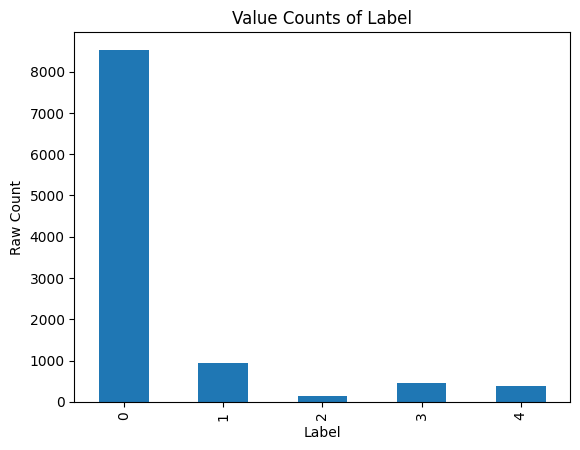

In [113]:
# Raw label counts & relative frequencies
def class_distr(dataset: pd.DataFrame):
    counts = dataset["label"].value_counts(sort=False)
    relative_freq = (dataset["label"].value_counts(sort=False, normalize=True) * 100).round(2)

    summary_df = pd.DataFrame({
        "count": counts,
        "relative_frequency": relative_freq
    })

    display(summary_df)

    # Bar plot (raw counts)
    plt.figure()
    counts.plot(kind="bar")
    plt.xlabel("Label")
    plt.ylabel("Raw Count")
    plt.title("Value Counts of Label")
    plt.show()

    return summary_df

distr = class_distr(raw_data)

**Analysis**: The label distribution reveals severe class imbalance, with 81.47% of samples labelled as having no/very weak PCL (labels 0/1) and only ~8% labelled as clear PCL (labels 3–4). This indicates that the dataset is heavily skewed toward non-PCL examples, which may bias a model toward predicting the majority class. Moreover, it could mean there is not sufficient data within the positive class for the model to learn meaningful patterns of patronising language.

In addition to this, Label 2 reflects annotator uncertainty, capturing instances where the language is sufficiently subtle to be interpreted as either PCL or non-PCL. As these examples do not form a clearly defined class, forcing them into either category risks introducing label noise and weakening the model’s ability to learn a consistent decision boundary about what constitutes PCL. Furthermore, label 2 constitutes only 1.38% of the dataset. Given this low frequency, removing these samples is unlikely to materially affect dataset size or representativeness, and may instead improve overall data quality by retaining only higher-confidence annotations.


**Impact**: To reduce annotation noise and create a clearer learning signal, label 2 samples will be removed. The remaining labels will be collapsed into a binary formulation: {0,1} → 0 (no PCL) and {3,4} → 1 (PCL).

,count,relative_frequency
label,,
0,9476,91.78
1,849,8.22


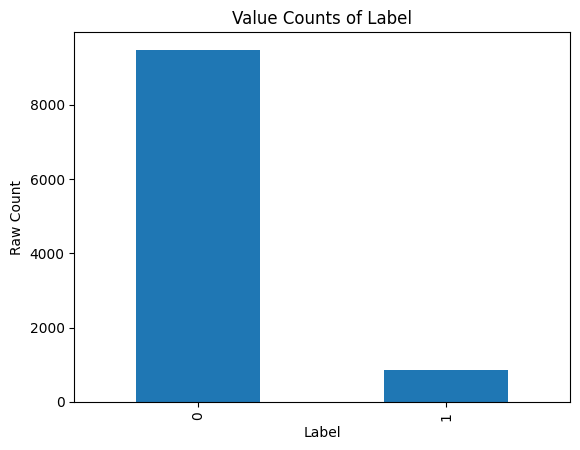

In [114]:
# Dropping label 2 from the dataset 

filtered_data = raw_data[raw_data["label"] != 2]

# Convert labels into a binary set.
label_map = {
    0: 0,  # no PCL
    1: 0,
    3: 1,  # PCL
    4: 1
}

filtered_data["label"] = filtered_data["label"].map(label_map)

# Recompute distribution statistics of binary task
distr = class_distr(filtered_data)



In [93]:
neg, pos = distr["count"][0], distr["count"][1]
print(f"No PCL : PCL ratio ≈ {neg/pos:.2f} : 1")

No PCL : PCL ratio ≈ 11.16 : 1


**Analysis & Impact**: As evident from the data and visualisations, i.e., an 11.16 : 1 Non PCL : PCL ratio, this label separation results in a strongly imbalanced binary dataset. Therefore, F1 score will be used as the primary evaluation metric, as it is more resistant to imbalanced data and reflects performance on the minority class better than accuracy. 

Moreover, additional mitigation strategies such as class weighting or targeted data augmentation of the possitive class may be necessary to ensure the model has sufficient training samples to effectively learn patterns associated with PCL.

### 2. Token Distribution
 -- What is the average, minimum, and maximum sentence length (in terms of tokens)?
As I plan to use the `RoBERTa-base` encoder model for this task, I will be utilising the `RoBERTa-base` tokeniser to compute all statistics regarding token counts and distributions. 

In [94]:
def token_lengths(texts, add_special_tokens=True):
    """Batch-tokenise and return token lengths (no padding/truncation)."""
    enc = tokenizer(
        ["" if t is None else str(t) for t in texts],
        padding=False,
        truncation=False,
        add_special_tokens=add_special_tokens,
    )
    return np.fromiter((len(ids) for ids in enc["input_ids"]), dtype=np.int32)

def summarise(arr: np.ndarray, name: str) -> pd.DataFrame:
    """Common stats for 1D numeric array."""
    if arr.size == 0:
        res = {"count": 0}
    
    res = {
        "min": int(arr.min()),
        "max": int(arr.max()),
        "mean": float(arr.mean()),
        "std": float(arr.std(ddof=0)),
        "median": float(np.median(arr)),
    }

    return pd.DataFrame(res, index=[name])


def plot_hist(arr: np.ndarray, title: str, bins: int = 50, xline=None, xlim=None):
    """Simple histogram with optional vertical line and x-limits."""
    plt.figure()
    plt.hist(arr, bins=bins)

    if xline is not None:
        plt.axvline(xline, linestyle="--")

    if xlim is not None:
        plt.xlim(xlim)

    plt.xlabel("Token length")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()


def overflow_metrics(arr: np.ndarray, max_len: int, name: str) -> tuple[pd.DataFrame, np.ndarray]:
    """Overflow fraction + overflow amount stats for arr > max_len."""
    if arr.size == 0:
        return pd.DataFrame({"max_len": max_len, "overflow_count": 0, "overflow_frac": 0.0}, index=[name]), np.ndarray(())
    
    mask = arr > max_len
    overflow_lens = arr[mask]

    overflow_count = int(mask.sum())
    overflow_frac = float(mask.mean())
    out = {"overflow_count": overflow_count, "overflow_frac": overflow_frac}

    # Compute statistics for overflow tokens
    if overflow_count:
        excess = overflow_lens - max_len
        out.update(
            {
                "excess_mean": float(excess.mean()),
                "excess_median": float(np.median(excess)),
                "excess_max": int(excess.max()),
            }
        )
    return pd.DataFrame(out, index=[name]), overflow_lens

In [95]:
# Tokenise dataset & compute statistics + distribution plot
texts = filtered_data["text"].tolist()
lengths = token_lengths(texts, add_special_tokens=True)

filtered_data["token_length"] = lengths

overall_stats = summarise(lengths, "overall")

Token indices sequence length is longer than the specified maximum sequence length for this model (545 > 512). Running this sequence through the model will result in indexing errors


RoBERTa model_max_length: 512

=== Overall Token Length statistics ===


,min,max,mean,std,median,overflow_count,overflow_frac,excess_mean,excess_median,excess_max
overall,3,1004,55.482615,32.254332,48.0,2,0.000194,262.5,262.5,492


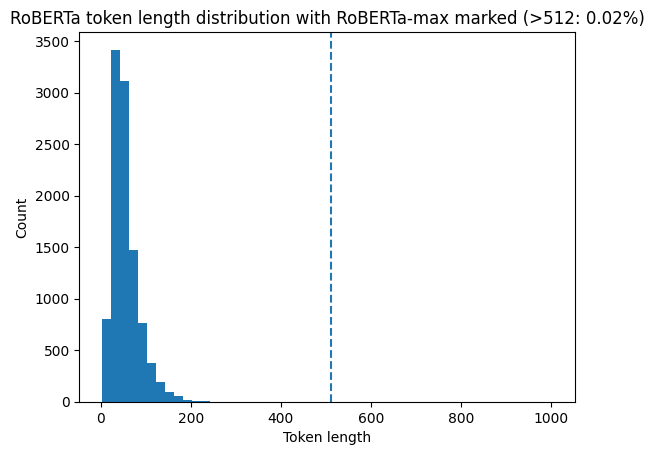

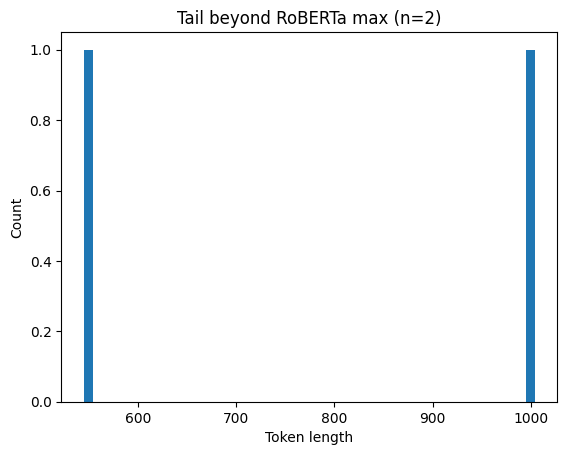

In [112]:
# Compute overflow statistics - how many tokenised inputs exceed model's maximum input size, and what is the distribution?

ROBERTA_MAX_LEN = tokenizer.model_max_length  # typically 512 for roberta-base

ov, overflow_lens = overflow_metrics(lengths, ROBERTA_MAX_LEN, "overall")

print(f"RoBERTa model_max_length: {ROBERTA_MAX_LEN}")

print("\n=== Overall Token Length statistics ===")
display(overall_stats.join(ov))

# Plot with max-length marker
plot_hist(
    lengths,
    f"RoBERTa token length distribution with RoBERTa-max marked (>{ROBERTA_MAX_LEN}: {ov['overflow_frac'].iloc[0]:.2%})",
    xline=ROBERTA_MAX_LEN,
)

too_long_mask = lengths > ROBERTA_MAX_LEN

# Tail-only plot (only sequences exceeding model limit)
tail = lengths[too_long_mask]
if tail.size:
    plot_hist(tail, f"Tail beyond RoBERTa max (n={tail.size})")
else:
    print("No samples exceed the RoBERTa max length.")

In [97]:
# Inspecting the overly long texts after
too_long_texts = filtered_data["text"].loc[too_long_mask].to_list()
too_long_encs = tokenizer(too_long_texts, truncation=True, max_length=ROBERTA_MAX_LEN)

truncated_texts = [tokenizer.decode(ids, skip_special_tokens=True) for ids in too_long_encs["input_ids"]]
truncated_texts

['Most are from desperately poor Horn of Africa countries and like tens of thousands each year , were willing to risk the treacherous journey through war-torn and impoverished Yemen in the hope of finding work in Saudi Arabia and other wealthy Gulf Arab states . But their plan was not to be . Caught and detained by the Yemeni authorities , the 600 or so men now await deportation , prevented from leaving their makeshift jail by armed soldiers . Conditions at the warehouse are growing increasingly desperate . Several days ago , the authorities stopped handing out food and basic supplies . " I came from Djibouti to work . They used to give us small amounts of food . If there is no food , we will die , " said one migrant who declined to give his name . " If there is no solution , they will deport us to our countries or get us out of here " , the man added . Yemen , the poorest country on the Arabian Peninsula , has long been a transit point for migrants and refugees from East Africa , many


=== Class-wise statistics ===

Label = 0


,min,max,mean,std,median,overflow_count,overflow_frac,excess_mean,excess_median,excess_max
No PCL,3,1004,54.979422,31.861272,48.0,1,0.000106,492.0,492.0,492



Label = 1


,min,max,mean,std,median,overflow_count,overflow_frac,excess_mean,excess_median,excess_max
PCL,9,545,61.09894,35.878306,54.0,1,0.001178,33.0,33.0,33


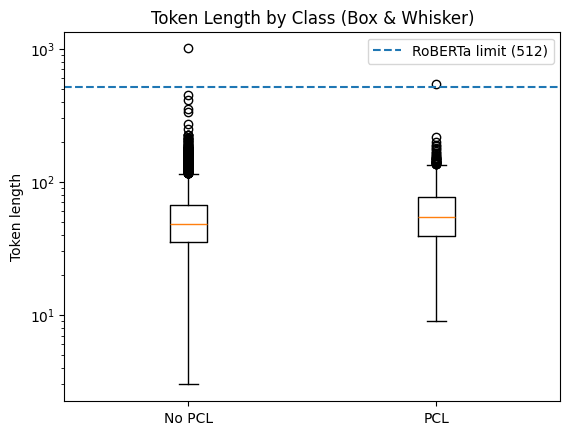

In [109]:
# Class-wise (label=0/1) stats + plots
print("\n=== Class-wise statistics ===")
for lab in [0, 1]:
    lab_mask = (filtered_data["label"] == lab).to_numpy()
    lab_lengths = lengths[lab_mask]

    name = "No PCL" if lab == 0 else "PCL"
    lab_stats = summarise(lab_lengths, name)
    lab_ov, _ = overflow_metrics(lab_lengths, ROBERTA_MAX_LEN, name)
    lab_metrics = lab_stats.join(lab_ov)

    print(f"\nLabel = {lab}")
    display(lab_metrics)

no_pcl = lengths[(filtered_data["label"] == 0).to_numpy()]
pcl    = lengths[(filtered_data["label"] == 1).to_numpy()]

plt.figure()
plt.boxplot(
    [no_pcl, pcl],
    tick_labels=["No PCL", "PCL"],
    showfliers=True,   # show outlier points (set False to hide)
)

plt.axhline(ROBERTA_MAX_LEN, linestyle="--", label=f"RoBERTa limit ({ROBERTA_MAX_LEN})")
plt.ylabel("Token length")
plt.yscale("log")
plt.title("Token Length by Class (Box & Whisker)")
plt.legend()
plt.show()


**Analysis**:

**Impact**: We have 2 examples which are larger than the tokenised input size supported by the model. We can simply truncate these, or drop them. In the case where the entire input is necessary to understand whether or not its PCL (i.e., the connotations, intention, or demeaning nature only becomes prevalent near the end), truncation could destroy the semantic meaning & thus make the input just noisy. However, after manual inspection of the inputs after truncation to 512 tokens, I chose to keep them, as even after truncation, they are rife with a lot of overt forms of PCL and can thus provide rich training signals. However, I just truncated them further to sentence boundaries to increase grammatical correctness & structure. 

 - Other than that, distributions roughly equal. Inputs are ~ same mean token length. [Top 75% < 100 tokens. Think about any other analysis u can draw]

In [ ]:
# Truncating the overly long texts to the last sentence <512 tokens.
fixed_truncated_texts = []

for txt in truncated_texts:
    last_period = txt.rfind(".")
    fixed_truncated_texts.append(txt[:last_period+1])

filtered_data.loc[too_long_mask, "text"] = fixed_truncated_texts

### 3. Vocabulary Size
 -- How many unique words exist? This dictates the size of your embedding layer.